In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from keras.models import Sequential, Model
from keras.layers import LSTM, Dense, Input, Layer
from keras.losses import MeanSquaredError
from keras.metrics import RootMeanSquaredError
from keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Attention, GlobalAveragePooling1D
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

In [2]:
data = pd.read_csv("/Users/iraklisdimitriadis/Documents/Μαθήματα-Σημειώσεις Data Science/Dissertation/Processed Data/cleaned_data_csv.csv", index_col= "datetime", parse_dates= True)
data.head()

,Kwh,name,temp,feelslike,dew,humidity,precip,snow,snowdepth,windgust,windspeed,winddir,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,conditions,icon
datetime,,,,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00,0.0,"Kozani, Greece",6.0,4.4,2.0,75.51,0.0,0.0,0.0,19.8,7.6,240.0,1023.0,0.0,NaN,0.0,0.0,0.0,Clear,clear-night
2022-01-01 01:00:00,0.0,"Kozani, Greece",6.0,5.0,2.0,75.51,0.0,0.0,0.0,19.8,5.4,298.1,1023.0,0.0,NaN,0.0,0.0,0.0,Clear,clear-night
2022-01-01 02:00:00,0.0,"Kozani, Greece",4.9,3.2,2.0,81.61,0.0,NaN,0.0,20.5,7.6,301.0,1022.4,40.9,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
2022-01-01 03:00:00,0.0,"Kozani, Greece",4.0,4.0,1.0,80.80,0.0,NaN,0.0,20.5,3.6,294.8,1022.0,38.0,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
2022-01-01 04:00:00,0.0,"Kozani, Greece",3.0,1.6,2.0,93.14,0.0,NaN,0.0,19.8,5.4,292.3,1021.0,41.7,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night


In [3]:
humidity = data['humidity']
humidity

datetime
2022-01-01 00:00:00    75.51
2022-01-01 01:00:00    75.51
2022-01-01 02:00:00    81.61
2022-01-01 03:00:00    80.80
2022-01-01 04:00:00    93.14
                       ...  
2024-07-04 19:00:00    41.15
2024-07-04 20:00:00    40.87
2024-07-04 21:00:00    49.39
2024-07-04 22:00:00    56.15
2024-07-04 23:00:00    63.61
Name: humidity, Length: 21983, dtype: float64

In [4]:
def df_to_x_y(df, size = 24):
    df_as_numpy = df.to_numpy()
    x = []
    y = []
    for i in range(len(df_as_numpy) - size):
        row = [[a] for a in df_as_numpy[i : i + size]]
        x.append(row)
        label = df_as_numpy[i + size]
        y.append(label)
    
    return np.array(x), np.array(y)

In [5]:
x, y = df_to_x_y(humidity, size= 24)

x.shape, y.shape

((21959, 24, 1), (21959,))

In [6]:
x_train = x[: int(0.8*len(x))]
y_train = y[: int(0.8*len(y))]

x_val = x[int(0.8*len(x)): int(0.9*len(x))]
y_val = y[int(0.8*len(y)): int(0.9*len(y))]

x_test = x[int(0.9*len(x)) :]
y_test = y[int(0.9*len(y)):]

x_train.shape, y_train.shape, x_val.shape, y_val.shape, x_test.shape, y_test.shape

((17567, 24, 1), (17567,), (2196, 24, 1), (2196,), (2196, 24, 1), (2196,))

In [7]:
checkpoint_callback = ModelCheckpoint(
    filepath='D:/Σπουδές/Μαθήματα-Σημειώσεις Data Science/Dissertation/Models.keras',
    monitor='val_loss',
    save_best_only=True, 
    mode='min',     
    save_weights_only=False,
    verbose=1 
)

In [8]:
input_shape = (24, 1)

inputs = Input(shape=input_shape)

lstm_out = LSTM(64, return_sequences=True)(inputs)
norm_out = BatchNormalization()(lstm_out)

query = norm_out
value = norm_out

attention_out = Attention()([query, value])
dropout_out = Dropout(0.2)(attention_out)
flattened = Dense(16, activation="relu")(dropout_out)
flattened = BatchNormalization()(flattened)
flattened = GlobalAveragePooling1D()(flattened)
outputs = Dense(1, activation="relu")(flattened)

model_1 = Model(inputs=inputs, outputs=outputs)

model_1.compile(
    loss=MeanSquaredError(),
    optimizer=Adam(learning_rate=1e-3),
    metrics=[RootMeanSquaredError()]
)

model_1.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 24, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 24, 64)    │     16,896 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 24, 64)    │        256 │ lstm[0][0]        │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 24, 64)    │          0 │ batch_normalizat… │
│ (Attention)         │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 24, 64)    │          0 │ attention[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 24, 16)    │      1,040 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 16)    │         64 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 16)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         17 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 18,273 (71.38 KB)

 Trainable params: 18,113 (70.75 KB)

 Non-trainable params: 160 (640.00 B)

In [9]:
model_1.fit(x_train, y_train, 
            validation_data = (x_val, y_val), 
            epochs = 40,
            batch_size= 32,
            callbacks=[checkpoint_callback]
            )

Epoch 1/40
547/549 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3619.8245 - root_mean_squared_error: 60.0963
Epoch 1: val_loss improved from inf to 1759.50916, saving model to D:/Σπουδές/Μαθήματα-Σημειώσεις Data Science/Dissertation/Models.keras
549/549 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 3616.4207 - root_mean_squared_error: 60.0670 - val_loss: 1759.5092 - val_root_mean_squared_error: 41.9436
Epoch 2/40
543/549 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1343.1060 - root_mean_squared_error: 36.5231
Epoch 2: val_loss improved from 1759.50916 to 886.22198, saving model to D:/Σπουδές/Μαθήματα-Σημειώσεις Data Science/Dissertation/Models.keras
549/549 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 1338.7539 - root_mean_squared_error: 36.4609 - val_loss: 886.2220 - val_root_mean_squared_error: 29.6852
Epoch 3/40
541/549 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 390.2864 - root_mean_squared_error: 19.7178
Epoch 3: val_loss improved from 886.22198 to 253.15900, saving model to D:/Σπουδές/Μαθήματα-Σημει

In [10]:
test_predictions = model_1.predict(x_test).flatten()
test_results = pd.DataFrame({"Val Predictions" : test_predictions, "Real Data" : y_test})
test_results
test_results.index = humidity.iloc[-2196:].index

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


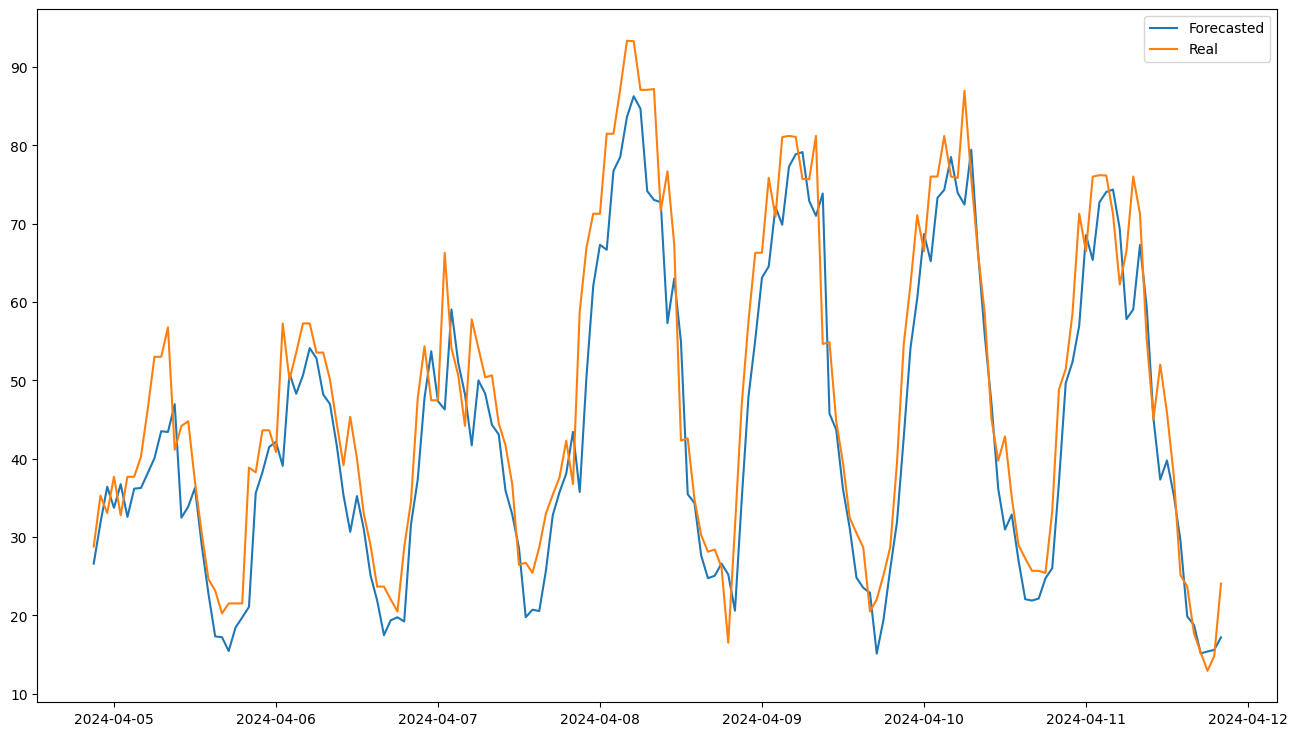

In [11]:
plt.figure(figsize= (16, 9))
plt.plot(test_results["Val Predictions"][9:177], label = "Forecasted")
plt.plot(test_results["Real Data"][9:177], label = "Real")
plt.legend()
plt.show()

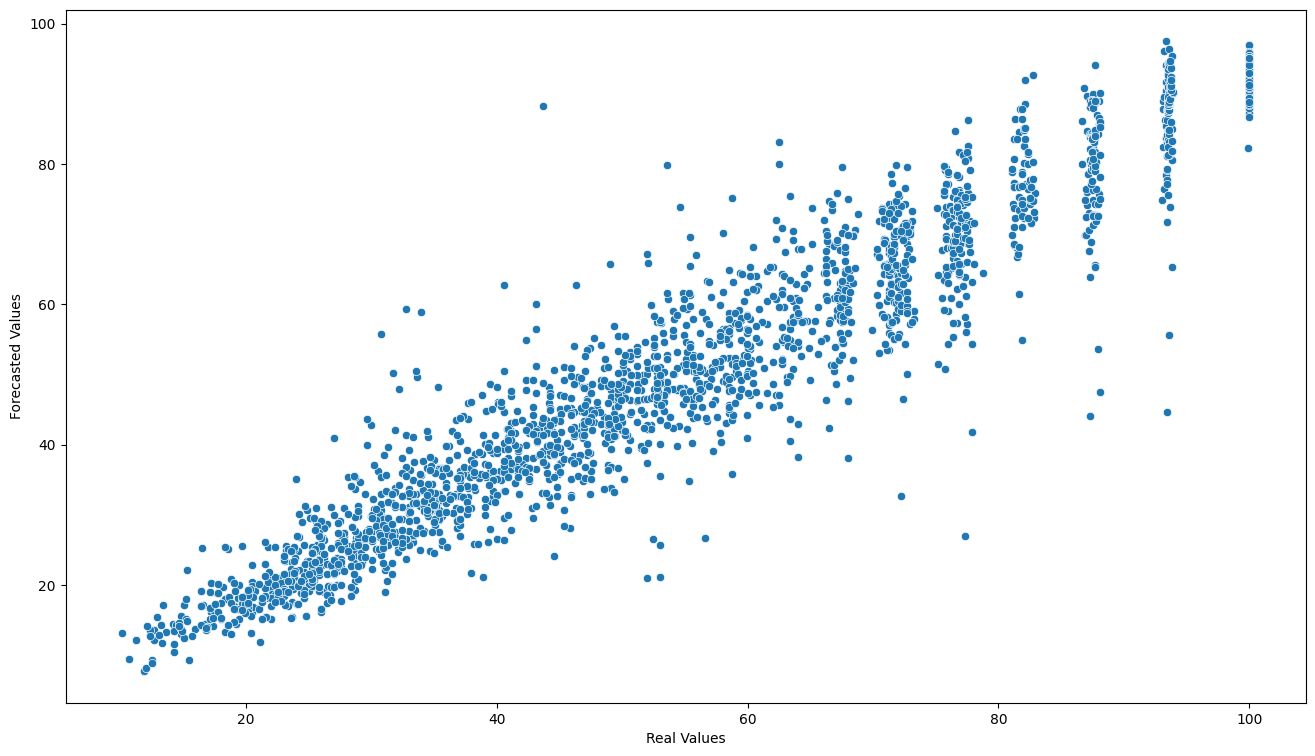

In [12]:
plt.figure(figsize= (16, 9))
sns.scatterplot(x = "Real Data", y = "Val Predictions", data = test_results)
plt.xlabel("Real Values")
plt.ylabel("Forecasted Values")
plt.show()

In [13]:
mse = mean_squared_error(test_results["Real Data"], test_results["Val Predictions"])
print(f" Mean Squared Error = {round(mse, 5)} \n Root Mean Squared Error = {round(np.sqrt(mse), 5)}")

ss_total = np.sum((test_results["Real Data"] - test_results["Real Data"].mean()) ** 2)
residual = np.sum((test_results["Real Data"] - test_results["Val Predictions"]) ** 2)
r_squared = 1 - (residual / ss_total)

r_squared

 Mean Squared Error = 63.9809 
 Root Mean Squared Error = 7.99881


0.8821145965856337